# PCA — Метод главных компонент

**Метод главных компонент (PCA)** — это техника уменьшения размерности,
которая ортогонально проецирует данные на новые оси — главные компоненты,
упорядоченные по убыванию объясняемой дисперсии.

## 2. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

## 3. Описание и демонстрация датасета

Digits — рукописные цифры 0–9, 64 признака (яркости пикселей 8×8).

In [2]:
digits = load_digits()
X = digits.data          # признаки (1797, 64)
y = digits.target        # целевая переменная (0-9)
feature_names = [f'pixel_{i}' for i in range(64)]
target_names = [str(i) for i in range(10)]

In [3]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].astype(str)


In [4]:
df['target'].value_counts().sort_index()

,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


## 4. Предварительная обработка

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация (PCA чувствителен к масштабу)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Тепловая карта

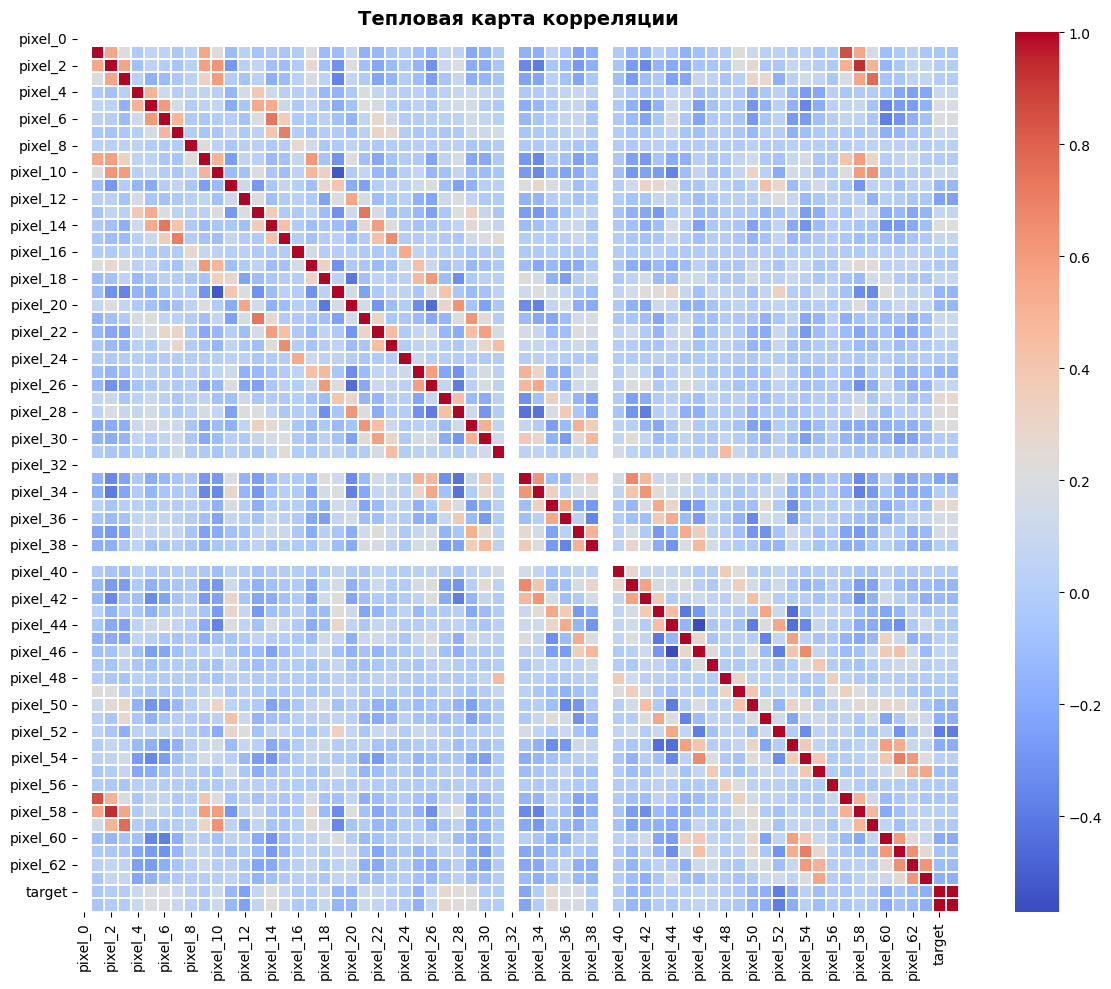

In [6]:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.1)
plt.title('Тепловая карта корреляции', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Обучение модели

Выберем оптимальное число компонент

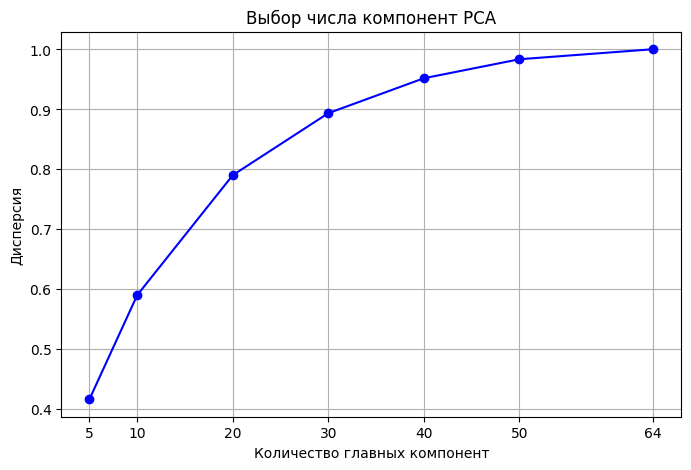

In [7]:
explained_ratios = []
components_range = [5, 10, 20, 30, 40, 50, 64]
for n in components_range:
    pca_temp = PCA(n_components=n)
    pca_temp.fit(X_train_scaled)
    explained_ratios.append(sum(pca_temp.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.plot(components_range, explained_ratios, 'bo-')
plt.xlabel('Количество главных компонент')
plt.ylabel('Дисперсия')
plt.title('Выбор числа компонент PCA')
plt.grid(True)
plt.xticks(components_range)
plt.show()

Выберем n=30, так как это сохранит 90% дисперсии

In [8]:
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Размерность после PCA: {X_train_pca.shape[1]}")
print(f"Суммарная объяснённая дисперсия для 30 компонент: {sum(pca.explained_variance_ratio_):.3f}")

# Классификатор (логистическая регрессия) на данных после PCA
clf_pca = LogisticRegression(random_state=42, max_iter=200)
clf_pca.fit(X_train_pca, y_train)

# Для сравнения: классификатор на исходных признаках (без PCA)
clf_orig = LogisticRegression(random_state=42, max_iter=200)
clf_orig.fit(X_train_scaled, y_train)

print("\nМодели успешно обучены.")

Размерность после PCA: 30
Суммарная объяснённая дисперсия для 30 компонент: 0.893

Модели успешно обучены.


# 7. Тестирование модели

In [9]:
y_pred_pca = clf_pca.predict(X_test_pca)
y_pred_orig = clf_orig.predict(X_test_scaled)

# 8. Обзор метрик

In [10]:
def print_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Матрица ошибок ({model_name})')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.show()

Посмотрим метрики для 30 компонент


--- Логистическая регрессия с PCA (30 компонент) ---
Accuracy:  0.9556
Precision: 0.9562
Recall:    0.9556
F1-score:  0.9557

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.89      0.86      0.87        36
           2       0.97      1.00      0.99        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      0.97      0.97        36
           7       1.00      1.00      1.00        36
           8       0.84      0.89      0.86        35
           9       0.94      0.94      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



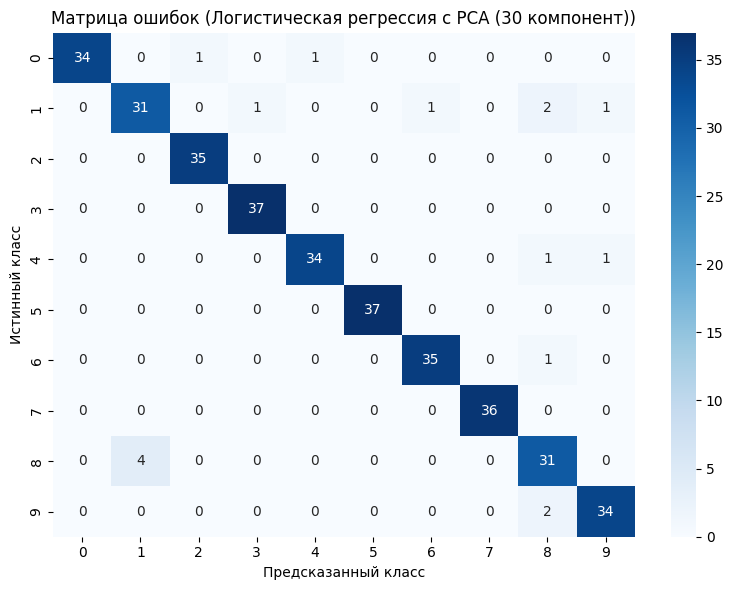

In [11]:
print_metrics(y_test, y_pred_pca, "Логистическая регрессия с PCA (30 компонент)")


Теперь для сравнения посмотрим метрики на изначальном количестве признаков


--- Логистическая регрессия на исходных признаках (64 признака) ---
Accuracy:  0.9722
Precision: 0.9724
Recall:    0.9722
F1-score:  0.9722

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



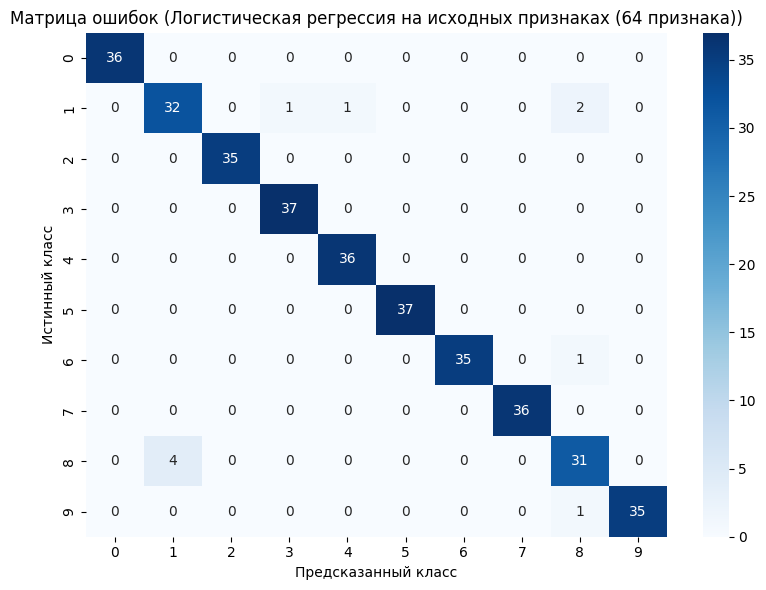

In [12]:
print_metrics(y_test, y_pred_orig, "Логистическая регрессия на исходных признаках (64 признака)")

# 8. Визуализация

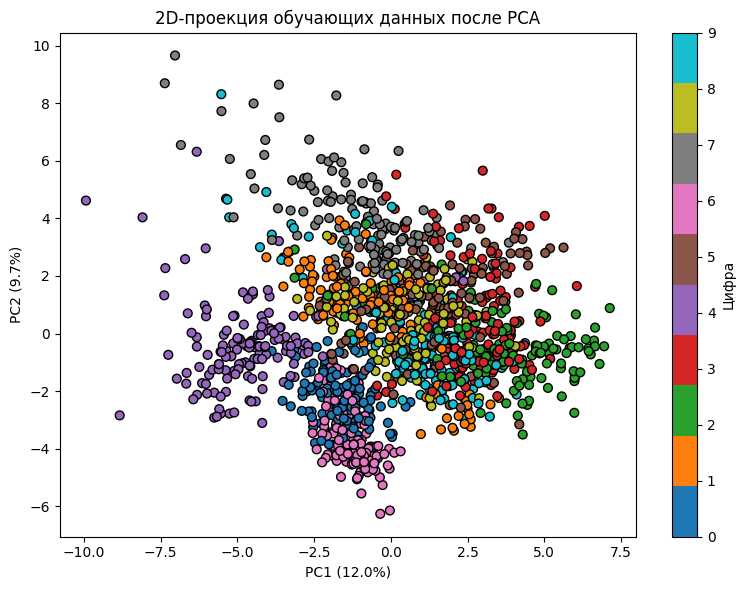

In [13]:
pca_2 = PCA(n_components=2, random_state=42)
X_2d = pca_2.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='tab10', edgecolor='k', s=40)
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('2D-проекция обучающих данных после PCA')
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.tight_layout()
plt.show()